# Dataset Preprocessing

In [1]:
import os
import re
import random
from pathlib import Path

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

In [2]:
DATA_ROOT = Path("../data")
REAL_DIR = DATA_ROOT / "real"
ALTERED_DIR = DATA_ROOT / "altered"

FINGER_LABELS = {
    "index_finger": 0,
    "little_finger": 1,
    "middle_finger": 2,
    "ring_finger": 3,
    "thumb_finger": 4,
}

ALTERATION_LABELS = {
    "CR": "Central Rotation", "Obl": "Obliteration", "Zcut": "Z-cut"
}

## 2. Data Loading

In [3]:
def parse_real_filename(filename: str) -> dict:
    """
    Parses a real fingerprint filename and extracts the subject ID, finger label, and image number.

    Args:
        filename (str): The filename to parse.
    
    Returns:
        dict: A dictionary containing the subject ID, finger label, and image number.
    """
    pattern = r"(\d+)__([MF])_(Left|Right)_(index|little|middle|ring|thumb)_finger\.BMP$"
    match = re.match(pattern, filename)
    if match:
        subject, gender, hand, finger = match.groups()
        return {
            "subject": int(subject),
            "gender": gender,
            "hand": hand,
            "finger": f"{finger}_finger",
            "label": FINGER_LABELS[f"{finger}_finger"],
            "filename": filename,
            "path": str(REAL_DIR / filename)
        }
    else:
        raise ValueError(f"Filename '{filename}' does not match the expected pattern for real fingerprints.")

In [4]:
real_samples = [parse_real_filename(f) for f in os.listdir(REAL_DIR) if f.endswith(".BMP")]
real_df = pd.DataFrame(real_samples)

In [5]:
real_df.head(10)

,subject,gender,hand,finger,label,filename,path
0,364,M,Right,little_finger,1,364__M_Right_little_finger.BMP,../data/real/364__M_Right_little_finger.BMP
1,292,M,Left,little_finger,1,292__M_Left_little_finger.BMP,../data/real/292__M_Left_little_finger.BMP
2,53,M,Left,thumb_finger,4,53__M_Left_thumb_finger.BMP,../data/real/53__M_Left_thumb_finger.BMP
3,225,M,Left,little_finger,1,225__M_Left_little_finger.BMP,../data/real/225__M_Left_little_finger.BMP
4,277,M,Right,middle_finger,2,277__M_Right_middle_finger.BMP,../data/real/277__M_Right_middle_finger.BMP
5,97,M,Right,little_finger,1,97__M_Right_little_finger.BMP,../data/real/97__M_Right_little_finger.BMP
6,503,M,Right,ring_finger,3,503__M_Right_ring_finger.BMP,../data/real/503__M_Right_ring_finger.BMP
7,426,M,Right,thumb_finger,4,426__M_Right_thumb_finger.BMP,../data/real/426__M_Right_thumb_finger.BMP
8,569,M,Left,ring_finger,3,569__M_Left_ring_finger.BMP,../data/real/569__M_Left_ring_finger.BMP
9,495,M,Right,index_finger,0,495__M_Right_index_finger.BMP,../data/real/495__M_Right_index_finger.BMP


In [6]:
def parse_altered_filename(filename: str, difficulty: str) -> dict:
    pattern = r"(\d+)__([MF])_(Left|Right)_(index|little|middle|ring|thumb)_finger_(CR|Obl|Zcut)\.BMP$"
    match = re.match(pattern, filename)
    if match:
        subject, gender, hand, finger, alteration = match.groups()
        return {
            "subject": int(subject),
            "gender": gender,
            "hand": hand,
            "finger": f"{finger}_finger",
            "label": FINGER_LABELS[f"{finger}_finger"],
            "alteration": alteration,
            "difficulty": difficulty,
            "filename": filename,
            "path": str(ALTERED_DIR / difficulty / filename)
        }
    else:
        raise ValueError(f"Filename '{filename}' does not match the expected pattern for altered fingerprints.")

In [7]:
altered_records = [parse_altered_filename(f, difficulty) for difficulty in ["altered-easy", "altered-medium", "altered-hard"] for f in os.listdir(ALTERED_DIR / difficulty) if f.endswith(".BMP")]
altered_df = pd.DataFrame(altered_records)

In [8]:
altered_df.head(10)

,subject,gender,hand,finger,label,alteration,difficulty,filename,path
0,247,M,Left,index_finger,0,Obl,altered-easy,247__M_Left_index_finger_Obl.BMP,../data/altered/altered-easy/247__M_Left_index...
1,242,M,Left,little_finger,1,Zcut,altered-easy,242__M_Left_little_finger_Zcut.BMP,../data/altered/altered-easy/242__M_Left_littl...
2,128,M,Left,middle_finger,2,CR,altered-easy,128__M_Left_middle_finger_CR.BMP,../data/altered/altered-easy/128__M_Left_middl...
3,202,M,Left,index_finger,0,CR,altered-easy,202__M_Left_index_finger_CR.BMP,../data/altered/altered-easy/202__M_Left_index...
4,465,F,Right,index_finger,0,CR,altered-easy,465__F_Right_index_finger_CR.BMP,../data/altered/altered-easy/465__F_Right_inde...
5,400,M,Left,little_finger,1,Obl,altered-easy,400__M_Left_little_finger_Obl.BMP,../data/altered/altered-easy/400__M_Left_littl...
6,545,M,Right,ring_finger,3,CR,altered-easy,545__M_Right_ring_finger_CR.BMP,../data/altered/altered-easy/545__M_Right_ring...
7,441,M,Left,little_finger,1,CR,altered-easy,441__M_Left_little_finger_CR.BMP,../data/altered/altered-easy/441__M_Left_littl...
8,357,M,Right,middle_finger,2,Zcut,altered-easy,357__M_Right_middle_finger_Zcut.BMP,../data/altered/altered-easy/357__M_Right_midd...
9,584,M,Right,middle_finger,2,Zcut,altered-easy,584__M_Right_middle_finger_Zcut.BMP,../data/altered/altered-easy/584__M_Right_midd...


## 3. Split Dataset into Train/Test Split

In [9]:
# Split by subject to prevent the same identity appearing in both train and test
subjects = real_df["subject"].unique()
train_subjects, test_subjects = train_test_split(subjects, test_size=0.2, random_state=42)
train_subjects, test_subjects = set(train_subjects), set(test_subjects)

train_real_df = real_df[real_df["subject"].isin(train_subjects)].reset_index(drop=True)
test_real_df = real_df[real_df["subject"].isin(test_subjects)].reset_index(drop=True)
train_altered_df = altered_df[altered_df["subject"].isin(train_subjects)].reset_index(drop=True)
test_altered_df = altered_df[altered_df["subject"].isin(test_subjects)].reset_index(drop=True)

In [10]:
print(f"Train Real: {len(train_real_df)}, Test Real: {len(test_real_df)}")
print(f"Train Altered: {len(train_altered_df)}, Test Altered: {len(test_altered_df)}")

Train Real: 4800, Test Real: 1200
Train Altered: 39426, Test Altered: 9844


## 4. Transforms

Training uses light augmentation (random rotation ±10°, horizontal flip). Test uses only deterministic resize and normalisation. Images are single-channel grayscale, resized to **96 × 96** px — the smallest native width in the dataset.

In [11]:
IMG_SIZE = 96

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

## 5. Custom Dataset — `FingerprintPairDataset`

Each `__getitem__` call samples a random pair using one of three strategies:

- **Genuine (50%, label=0):** Same subject, same finger — Left vs Right hand
- **Impostor A (25%, label=1):** Real vs its own altered version (forgery detection)
- **Impostor B (25%, label=1):** Real vs a different subject's real image (identity boundary)

`__len__` returns a *virtual* size (`num_pairs`) — each epoch draws a fresh random sample, so the model never sees identical pairs twice across epochs.

In [12]:
class FingerprintPairDataset(Dataset):
    def __init__(self, real_df, altered_df, num_pairs: int = 20_000, transform=None):
        self.num_pairs = num_pairs
        self.transform = transform

        self.real_by_identity = (
            real_df.groupby(["subject", "finger"])["path"]
            .apply(list).to_dict()
        )
        self.altered_by_identity = (
            altered_df.groupby(["subject", "finger"])["path"]
            .apply(list).to_dict()
        )
        self.identities = list(self.real_by_identity.keys())
        self.identities_with_altered = [
            k for k in self.identities if k in self.altered_by_identity
        ]

    def __len__(self):
        return self.num_pairs

    def _load(self, path: str):
        img = Image.open(path).convert("L")
        if self.transform:
            img = self.transform(img)
        return img

    def __getitem__(self, _idx):
        r = random.random()

        if r < 0.5:
            # Genuine: same subject, same finger — draws from L and R hand images
            key = random.choice(self.identities)
            paths = self.real_by_identity[key]
            p1, p2 = random.choices(paths, k=2)
            label = 0

        elif r < 0.75:
            # Impostor A: real vs its own altered version (forgery detection)
            key = random.choice(self.identities_with_altered)
            p1 = random.choice(self.real_by_identity[key])
            p2 = random.choice(self.altered_by_identity[key])
            label = 1

        else:
            # Impostor B: real vs a completely different subject's real (identity boundary)
            k1, k2 = random.sample(self.identities, 2)
            p1 = random.choice(self.real_by_identity[k1])
            p2 = random.choice(self.real_by_identity[k2])
            label = 1

        return (
            self._load(p1),
            self._load(p2),
            torch.tensor(label, dtype=torch.float32),
        )

In [13]:
TRAIN_PAIRS = 20_000
TEST_PAIRS = 4_000

train_dataset = FingerprintPairDataset(
    train_real_df, train_altered_df,
    num_pairs=TRAIN_PAIRS,
    transform=train_transform,
)
test_dataset = FingerprintPairDataset(
    test_real_df, test_altered_df,
    num_pairs=TEST_PAIRS,
    transform=test_transform,
)

print(f"Train dataset : {len(train_dataset):,} pairs  ({len(train_subjects)} subjects)")
print(f"Test dataset  : {len(test_dataset):,} pairs  ({len(test_subjects)} subjects)")

Train dataset : 20,000 pairs  (480 subjects)
Test dataset  : 4,000 pairs  (120 subjects)


## 6. DataLoaders

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = 0

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 625
Test batches  : 125


## 7. Batch Verification

Sanity-check: draw one batch and display 8 pairs side-by-side with their labels.

img1 shape : torch.Size([32, 1, 96, 96])
img2 shape : torch.Size([32, 1, 96, 96])
labels     : [0, 0, 0, 1, 0, 0, 1, 1]
Genuine in batch  : 22
Impostor in batch : 10


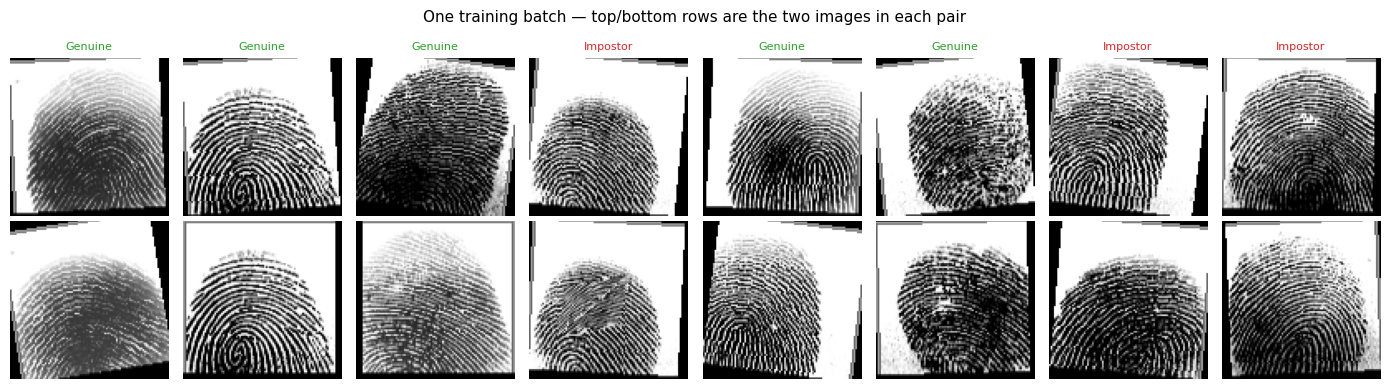

In [16]:
img1_batch, img2_batch, label_batch = next(iter(train_loader))

print(f"img1 shape : {img1_batch.shape}")
print(f"img2 shape : {img2_batch.shape}")
print(f"labels     : {label_batch[:8].int().tolist()}")
print(f"Genuine in batch  : {(label_batch == 0).sum().item()}")
print(f"Impostor in batch : {(label_batch == 1).sum().item()}")

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

n = 8
fig, axes = plt.subplots(2, n, figsize=(14, 4))
for i in range(n):
    lbl = int(label_batch[i].item())
    color = "#2ca02c" if lbl == 0 else "#d62728"
    title = "Genuine" if lbl == 0 else "Impostor"

    axes[0, i].imshow(denorm(img1_batch[i]).squeeze(), cmap="gray")
    axes[0, i].set_title(title, fontsize=8, color=color)
    axes[0, i].axis("off")

    axes[1, i].imshow(denorm(img2_batch[i]).squeeze(), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Image 1", fontsize=9)
axes[1, 0].set_ylabel("Image 2", fontsize=9)
plt.suptitle("One training batch — top/bottom rows are the two images in each pair", fontsize=11)
plt.tight_layout()
plt.show()